# BERT + Graph Feature Fusion for Rumor Detection

## Objective
Integrate sentence-level semantic embeddings from pre-trained MiniLM encoder (384 dimensions) with handcrafted Knowledge Graph features to improve rumor detection recall beyond the current best of 0.7775.

## Architecture
```
Sentence embedding (384-dim) from MiniLM encoder
    ↓ normalize
Graph handcrafted features (14-dim)
    ↓ normalize
Propagation features (4-dim)
    ↓ normalize
    ↓ concatenate
Logistic Regression classifier
```

## Experiment Matrix (Ablation Study)
| Experiment | Text Features | Propagation | Graph Features | Purpose |
|------------|---------------|-------------|----------------|---------|
| A) BERT only | MiniLM (384) | ✗ | ✗ | Semantic embedding standalone |
| B) BERT + propagation | MiniLM (384) | ✓ | ✗ | Add conversation structure |
| C) BERT + graph | MiniLM (384) | ✗ | ✓ | Add KG signals |
| D) Full fusion | MiniLM (384) | ✓ | ✓ | Complete feature set |

## Comparison Baselines
- **Original baseline**: TF-IDF (5000) + propagation features
- **Best graph model**: TF-IDF + propagation + all graph features (Exp3 from notebook 04)

## Critical Constraints (DO NOT BREAK)
- **NEVER** modify `data/processed/pheme_features.csv` or `data/processed/pheme_kg.ttl`
- **ALWAYS** use `RANDOM_STATE=42` for train/test split
- **ALWAYS** use stratified 80/20 split
- **NEVER** fit BERT on dataset (pre-trained model is fixed)
- **ALWAYS** normalize features: fit on train, transform both train/test
- **PRESERVE** interpretability of graph handcrafted features

In [47]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    matthews_corrcoef
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path for imports
import sys
sys.path.append('..')

from utils.bert_feature_fusion import (
    load_bert_model,
    extract_sentence_embeddings,
    create_fusion_feature_matrix,
    get_feature_dimension_breakdown
)
from utils.graph_features import get_graph_feature_columns

# Constants - DO NOT MODIFY
RANDOM_STATE = 42
TEST_SIZE = 0.2

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Frozen Dataset

In [48]:
# Load the frozen feature dataset
df = pd.read_csv('../data/processed/pheme_features.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nLabel distribution:")
print(df['label'].value_counts(normalize=True).map('{:.2%}'.format))
print(f"\nTotal posts: {len(df):,}")
print(f"Non-rumor: {(df['label'] == 0).sum():,} ({df['label'].mean():.1%})")
print(f"Rumor: {(df['label'] == 1).sum():,} ({1 - df['label'].mean():.1%})")

Dataset shape: (102440, 17)

Columns: ['post_id', 'user_id', 'text', 'time', 'event_id', 'reply_to', 'thread_id', 'label', 'depth', 'children_count', 'time_since_source', 'is_source', 'thread_size', 'thread_duration_hours', 'first_reply_time_seconds', 'reply_speed_per_hour', 'max_depth']

Label distribution:
label
0    69.51%
1    30.49%
Name: proportion, dtype: object

Total posts: 102,440
Non-rumor: 71,210 (30.5%)
Rumor: 31,230 (69.5%)


## 2. Create Frozen Train/Test Split

In [49]:
# Create train/test split (frozen, same as all previous experiments)
y = df['label']
indices = np.arange(len(df))

X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    indices, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Create dataframes for train and test subsets
df_train = df.iloc[X_train_idx].copy()
df_test = df.iloc[X_test_idx].copy()

print(f"Train set: {len(X_train_idx):,} samples")
print(f"Test set: {len(X_test_idx):,} samples")
print(f"Train rumor ratio: {y_train.mean():.3f}")
print(f"Test rumor ratio: {y_test.mean():.3f}")

Train set: 81,952 samples
Test set: 20,488 samples
Train rumor ratio: 0.305
Test rumor ratio: 0.305


## 3. Extract Graph Features (for fusion experiments)

We extract graph features from the frozen KG to use in fusion experiments. This follows the same pipeline as notebook 04.

In [50]:
from utils.graph_features import extract_all_graph_features, get_graph_feature_columns

# Extract all graph features from the frozen KG
print("Extracting graph features from knowledge graph...")
df_enriched = extract_all_graph_features(df, kg_path='../data/processed/pheme_kg.ttl')

graph_cols = get_graph_feature_columns()
print(f"Added {len(graph_cols)} graph features")
print(f"\nGraph feature columns:")
for col in graph_cols:
    print(f"  - {col}")

2026-04-07 16:53:49,136 - INFO - Starting complete graph feature extraction pipeline...
2026-04-07 16:53:49,154 - INFO - Processing 102440 unique posts
2026-04-07 16:53:49,154 - INFO - Building reply graph from ../data/processed/pheme_kg.ttl


Extracting graph features from knowledge graph...


2026-04-07 16:54:21,366 - INFO - Loaded KG with 1065885 triples
2026-04-07 16:54:21,447 - INFO - Built reply graph with 0 nodes and 0 edges
2026-04-07 16:54:21,447 - INFO - Computing node centrality features...
2026-04-07 16:54:21,448 - INFO - Computing PageRank...
2026-04-07 16:54:21,449 - INFO - Computing betweenness centrality...
2026-04-07 16:54:21,449 - INFO - Computing closeness centrality...
2026-04-07 16:54:21,586 - INFO - Computed centrality features for 102440 posts
2026-04-07 16:54:21,594 - INFO - Computing user reputation features...
2026-04-07 16:54:21,614 - INFO - Computed reputation features for 49345 users
2026-04-07 16:54:21,615 - INFO - Computing thread structure features...
2026-04-07 16:54:23,330 - INFO - Computed thread structure features for 102440 posts
2026-04-07 16:54:23,344 - INFO - Computing source authority features...
2026-04-07 16:54:23,419 - INFO - Computed source authority features for 1434577 posts
2026-04-07 16:54:23,430 - INFO - Merging all graph feat

Added 14 graph features

Graph feature columns:
  - node_in_degree
  - node_out_degree
  - pagerank_score
  - betweenness_centrality
  - closeness_centrality
  - user_prior_rumor_ratio
  - user_post_count
  - user_thread_count
  - user_avg_depth
  - subtree_reply_count
  - sibling_count
  - position_in_thread
  - source_user_credibility
  - source_network_size


## 4. Load BERT Model

In [51]:
# Load pre-trained MiniLM model
print("Loading BERT model (all-MiniLM-L6-v2)...")
bert_model = load_bert_model()
print(f"Model loaded. Will produce {384}-dimensional sentence embeddings.")

2026-04-07 16:54:23,961 - INFO - Loading BERT model: all-MiniLM-L6-v2
2026-04-07 16:54:23,963 - INFO - Use pytorch device_name: cpu
2026-04-07 16:54:23,965 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2


Loading BERT model (all-MiniLM-L6-v2)...


2026-04-07 16:54:24,560 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-04-07 16:54:24,662 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
2026-04-07 16:54:24,933 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-04-07 16:54:24,971 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-04-07 16:54:25,258 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Red

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-07 16:54:27,336 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-07 16:54:27,427 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config.json "HTTP/1.1 200 OK"
2026-04-07 16:54:27,694 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-04-07 16:54:27,734 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transfor

Model loaded. Will produce 384-dimensional sentence embeddings.


## 5. Baseline Model (Reproduction)

First, we reproduce the exact baseline model to ensure our comparison is valid.

In [52]:
# Extract TF-IDF features (fit ONLY on training text!)
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['text'])
X_test_tfidf = tfidf_vectorizer.transform(df_test['text'])

print(f"TF-IDF features: {X_train_tfidf.shape[1]}")

TF-IDF features: 5000


In [53]:
# Extract propagation features
# Note: is_reply is derived from depth (depth > 0 means it's a reply)
df['is_reply'] = (df['depth'] > 0).astype(int)
df_train['is_reply'] = (df_train['depth'] > 0).astype(int)
df_test['is_reply'] = (df_test['depth'] > 0).astype(int)
df_enriched['is_reply'] = (df_enriched['depth'] > 0).astype(int)
propagation_cols = ['is_reply', 'thread_size', 'children_count', 'depth']

X_train_propagation = df_train[propagation_cols].values
X_test_propagation = df_test[propagation_cols].values

# Scale propagation features
prop_scaler = StandardScaler()
X_train_propagation_scaled = prop_scaler.fit_transform(X_train_propagation)
X_test_propagation_scaled = prop_scaler.transform(X_test_propagation)

print(f"Propagation features: {X_train_propagation.shape[1]}")

Propagation features: 4


In [54]:
# Combine TF-IDF and propagation features
X_train_baseline = hstack([X_train_tfidf, X_train_propagation_scaled])
X_test_baseline = hstack([X_test_tfidf, X_test_propagation_scaled])

print(f"Baseline feature dimension: {X_train_baseline.shape[1]}")

Baseline feature dimension: 5004


In [55]:
# Train baseline model
baseline_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)
baseline_model.fit(X_train_baseline, y_train)

# Predict
y_pred_baseline = baseline_model.predict(X_test_baseline)
y_pred_proba_baseline = baseline_model.predict_proba(X_test_baseline)[:, 1]

# Evaluate
baseline_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_baseline),
    'Precision': precision_score(y_test, y_pred_baseline, pos_label=1),
    'Recall': recall_score(y_test, y_pred_baseline, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_baseline, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_baseline),
    'MCC': matthews_corrcoef(y_test, y_pred_baseline),
}

print("=" * 60)
print("BASELINE MODEL RESULTS (TF-IDF + Propagation)")
print("=" * 60)
for metric, value in baseline_metrics.items():
    print(f"{metric:12s}: {value:.4f}")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=['Non-Rumor', 'Rumor']))

BASELINE MODEL RESULTS (TF-IDF + Propagation)
Accuracy    : 0.8065
Precision   : 0.6545
Recall      : 0.7735
F1-Score    : 0.7090
ROC-AUC     : 0.8847
MCC         : 0.5700

Classification Report:
              precision    recall  f1-score   support

   Non-Rumor       0.89      0.82      0.86     14242
       Rumor       0.65      0.77      0.71      6246

    accuracy                           0.81     20488
   macro avg       0.77      0.80      0.78     20488
weighted avg       0.82      0.81      0.81     20488



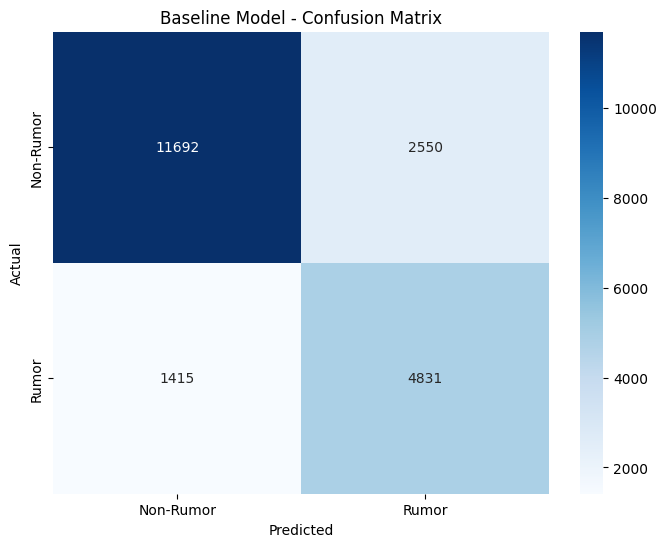

False Negatives (missed rumors): 1415
True Positives (correct rumors): 4831


In [56]:
# Visualize baseline confusion matrix
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Rumor', 'Rumor'],
            yticklabels=['Non-Rumor', 'Rumor'])
plt.title('Baseline Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"False Negatives (missed rumors): {cm_baseline[1, 0]}")
print(f"True Positives (correct rumors): {cm_baseline[1, 1]}")

## 6. Best Graph Model (Reproduction from Notebook 04)

Reproduce the best model from the previous graph feature experiments for comparison.

In [57]:
# Extract graph features for train/test
X_train_graph = df_enriched.iloc[X_train_idx][graph_cols].values
X_test_graph = df_enriched.iloc[X_test_idx][graph_cols].values

# Scale graph features
graph_scaler = StandardScaler()
X_train_graph_scaled = graph_scaler.fit_transform(X_train_graph)
X_test_graph_scaled = graph_scaler.transform(X_test_graph)

print(f"Graph features: {X_train_graph.shape[1]}")

Graph features: 14


In [58]:
# Combine baseline + graph features
X_train_graph_model = hstack([X_train_baseline, X_train_graph_scaled])
X_test_graph_model = hstack([X_test_baseline, X_test_graph_scaled])

print(f"Graph model feature dimension: {X_train_graph_model.shape[1]}")

Graph model feature dimension: 5018


In [59]:
# Train graph model
graph_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)
graph_model.fit(X_train_graph_model, y_train)

# Predict
y_pred_graph = graph_model.predict(X_test_graph_model)
y_pred_proba_graph = graph_model.predict_proba(X_test_graph_model)[:, 1]

# Evaluate
graph_model_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_graph),
    'Precision': precision_score(y_test, y_pred_graph, pos_label=1),
    'Recall': recall_score(y_test, y_pred_graph, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_graph, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_graph),
    'MCC': matthews_corrcoef(y_test, y_pred_graph),
}

print("=" * 60)
print("BEST GRAPH MODEL RESULTS (TF-IDF + Propagation + Graph)")
print("=" * 60)
for metric, value in graph_model_metrics.items():
    baseline_val = baseline_metrics[metric]
    diff = value - baseline_val
    arrow = '↑' if diff > 0 else '↓' if diff < 0 else '='
    print(f"{metric:12s}: {value:.4f} ({arrow} {abs(diff):.4f})")
print("=" * 60)

BEST GRAPH MODEL RESULTS (TF-IDF + Propagation + Graph)
Accuracy    : 0.8092 (↑ 0.0027)
Precision   : 0.6584 (↑ 0.0039)
Recall      : 0.7775 (↑ 0.0040)
F1-Score    : 0.7130 (↑ 0.0040)
ROC-AUC     : 0.8858 (↑ 0.0010)
MCC         : 0.5760 (↑ 0.0060)


## 7. BERT Embedding Extraction

Extract sentence-level semantic embeddings using the pre-trained MiniLM encoder. These are pooled sentence embeddings (384 dimensions), not raw [CLS] token hidden states.

In [60]:
# Extract BERT embeddings for all data
print("Extracting BERT sentence embeddings for training set...")
X_bert_train = extract_sentence_embeddings(df_train['text'].tolist(), bert_model, batch_size=32, show_progress=True)

print("\nExtracting BERT sentence embeddings for test set...")
X_bert_test = extract_sentence_embeddings(df_test['text'].tolist(), bert_model, batch_size=32, show_progress=True)

print(f"\nBERT train embeddings shape: {X_bert_train.shape}")
print(f"BERT test embeddings shape: {X_bert_test.shape}")

2026-04-07 16:54:33,786 - INFO - Extracting sentence embeddings for 81952 texts


Extracting BERT sentence embeddings for training set...


Batches:   0%|          | 0/2561 [00:00<?, ?it/s]

2026-04-07 17:00:29,048 - INFO - Extracted embeddings shape: (81952, 384)
2026-04-07 17:00:29,055 - INFO - Extracting sentence embeddings for 20488 texts



Extracting BERT sentence embeddings for test set...


Batches:   0%|          | 0/641 [00:00<?, ?it/s]

2026-04-07 17:01:56,406 - INFO - Extracted embeddings shape: (20488, 384)



BERT train embeddings shape: (81952, 384)
BERT test embeddings shape: (20488, 384)


## 8. Ablation Study: BERT Fusion Experiments

### Experiment A: BERT Only
Sentence embeddings alone without any structural features.

In [61]:
# Train BERT-only model
bert_only_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)
bert_only_model.fit(X_bert_train, y_train)

# Predict
y_pred_bert_only = bert_only_model.predict(X_bert_test)
y_pred_proba_bert_only = bert_only_model.predict_proba(X_bert_test)[:, 1]

# Evaluate
bert_only_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_bert_only),
    'Precision': precision_score(y_test, y_pred_bert_only, pos_label=1),
    'Recall': recall_score(y_test, y_pred_bert_only, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_bert_only, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_bert_only),
    'MCC': matthews_corrcoef(y_test, y_pred_bert_only),
}

print("=" * 60)
print("EXPERIMENT A: BERT Only (Sentence Embeddings)")
print("=" * 60)
for metric, value in bert_only_metrics.items():
    baseline_val = baseline_metrics[metric]
    diff = value - baseline_val
    arrow = '↑' if diff > 0 else '↓' if diff < 0 else '='
    print(f"{metric:12s}: {value:.4f} ({arrow} {abs(diff):.4f})")
print("=" * 60)

cm_bert_only = confusion_matrix(y_test, y_pred_bert_only)
print(f"\nFalse Negatives: {cm_bert_only[1, 0]}, True Positives: {cm_bert_only[1, 1]}")

EXPERIMENT A: BERT Only (Sentence Embeddings)
Accuracy    : 0.6865 (↓ 0.1200)
Precision   : 0.4894 (↓ 0.1651)
Recall      : 0.6543 (↓ 0.1191)
F1-Score    : 0.5600 (↓ 0.1491)
ROC-AUC     : 0.7413 (↓ 0.1434)
MCC         : 0.3325 (↓ 0.2375)

False Negatives: 2159, True Positives: 4087


### Experiment B: BERT + Propagation Features
Adding conversation structure features to semantic embeddings.

In [62]:
# Fuse BERT + propagation
X_train_bert_prop = np.hstack([X_bert_train, X_train_propagation_scaled])
X_test_bert_prop = np.hstack([X_bert_test, X_test_propagation_scaled])

print(f"BERT + Propagation dimension: {X_train_bert_prop.shape[1]}")

BERT + Propagation dimension: 388


In [63]:
# Train BERT + propagation model
bert_prop_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)
bert_prop_model.fit(X_train_bert_prop, y_train)

# Predict
y_pred_bert_prop = bert_prop_model.predict(X_test_bert_prop)
y_pred_proba_bert_prop = bert_prop_model.predict_proba(X_test_bert_prop)[:, 1]

# Evaluate
bert_prop_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_bert_prop),
    'Precision': precision_score(y_test, y_pred_bert_prop, pos_label=1),
    'Recall': recall_score(y_test, y_pred_bert_prop, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_bert_prop, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_bert_prop),
    'MCC': matthews_corrcoef(y_test, y_pred_bert_prop),
}

print("=" * 60)
print("EXPERIMENT B: BERT + Propagation Features")
print("=" * 60)
for metric, value in bert_prop_metrics.items():
    baseline_val = baseline_metrics[metric]
    diff = value - baseline_val
    arrow = '↑' if diff > 0 else '↓' if diff < 0 else '='
    print(f"{metric:12s}: {value:.4f} ({arrow} {abs(diff):.4f})")
print("=" * 60)

cm_bert_prop = confusion_matrix(y_test, y_pred_bert_prop)
print(f"\nFalse Negatives: {cm_bert_prop[1, 0]}, True Positives: {cm_bert_prop[1, 1]}")

EXPERIMENT B: BERT + Propagation Features
Accuracy    : 0.6875 (↓ 0.1189)
Precision   : 0.4907 (↓ 0.1638)
Recall      : 0.6574 (↓ 0.1161)
F1-Score    : 0.5619 (↓ 0.1471)
ROC-AUC     : 0.7452 (↓ 0.1395)
MCC         : 0.3354 (↓ 0.2346)

False Negatives: 2140, True Positives: 4106


### Experiment C: BERT + Graph Features
Adding Knowledge Graph handcrafted features to semantic embeddings.

In [64]:
# Fuse BERT + graph
X_train_bert_graph = np.hstack([X_bert_train, X_train_graph_scaled])
X_test_bert_graph = np.hstack([X_bert_test, X_test_graph_scaled])

print(f"BERT + Graph dimension: {X_train_bert_graph.shape[1]}")

BERT + Graph dimension: 398


In [65]:
# Train BERT + graph model
bert_graph_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)
bert_graph_model.fit(X_train_bert_graph, y_train)

# Predict
y_pred_bert_graph = bert_graph_model.predict(X_test_bert_graph)
y_pred_proba_bert_graph = bert_graph_model.predict_proba(X_test_bert_graph)[:, 1]

# Evaluate
bert_graph_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_bert_graph),
    'Precision': precision_score(y_test, y_pred_bert_graph, pos_label=1),
    'Recall': recall_score(y_test, y_pred_bert_graph, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_bert_graph, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_bert_graph),
    'MCC': matthews_corrcoef(y_test, y_pred_bert_graph),
}

print("=" * 60)
print("EXPERIMENT C: BERT + Graph Features")
print("=" * 60)
for metric, value in bert_graph_metrics.items():
    baseline_val = baseline_metrics[metric]
    diff = value - baseline_val
    arrow = '↑' if diff > 0 else '↓' if diff < 0 else '='
    print(f"{metric:12s}: {value:.4f} ({arrow} {abs(diff):.4f})")
print("=" * 60)

cm_bert_graph = confusion_matrix(y_test, y_pred_bert_graph)
print(f"\nFalse Negatives: {cm_bert_graph[1, 0]}, True Positives: {cm_bert_graph[1, 1]}")

EXPERIMENT C: BERT + Graph Features
Accuracy    : 0.6921 (↓ 0.1144)
Precision   : 0.4963 (↓ 0.1582)
Recall      : 0.6646 (↓ 0.1089)
F1-Score    : 0.5682 (↓ 0.1408)
ROC-AUC     : 0.7497 (↓ 0.1350)
MCC         : 0.3454 (↓ 0.2246)

False Negatives: 2095, True Positives: 4151


### Experiment D: Full Fusion (BERT + Propagation + Graph)
Complete feature set combining semantic, structural, and knowledge graph signals.

In [66]:
# Fuse BERT + propagation + graph
X_train_full = np.hstack([X_bert_train, X_train_propagation_scaled, X_train_graph_scaled])
X_test_full = np.hstack([X_bert_test, X_test_propagation_scaled, X_test_graph_scaled])

print(f"Full fusion dimension: {X_train_full.shape[1]}")

Full fusion dimension: 402


In [67]:
# Train full fusion model
full_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)
full_model.fit(X_train_full, y_train)

# Predict
y_pred_full = full_model.predict(X_test_full)
y_pred_proba_full = full_model.predict_proba(X_test_full)[:, 1]

# Evaluate
full_model_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_full),
    'Precision': precision_score(y_test, y_pred_full, pos_label=1),
    'Recall': recall_score(y_test, y_pred_full, pos_label=1),
    'F1-Score': f1_score(y_test, y_pred_full, pos_label=1),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_full),
    'MCC': matthews_corrcoef(y_test, y_pred_full),
}

print("=" * 60)
print("EXPERIMENT D: Full Fusion (BERT + Propagation + Graph)")
print("=" * 60)
for metric, value in full_model_metrics.items():
    baseline_val = baseline_metrics[metric]
    diff = value - baseline_val
    arrow = '↑' if diff > 0 else '↓' if diff < 0 else '='
    print(f"{metric:12s}: {value:.4f} ({arrow} {abs(diff):.4f})")
print("=" * 60)

cm_full = confusion_matrix(y_test, y_pred_full)
print(f"\nFalse Negatives: {cm_full[1, 0]}, True Positives: {cm_full[1, 1]}")

EXPERIMENT D: Full Fusion (BERT + Propagation + Graph)
Accuracy    : 0.6929 (↓ 0.1135)
Precision   : 0.4973 (↓ 0.1572)
Recall      : 0.6691 (↓ 0.1044)
F1-Score    : 0.5706 (↓ 0.1385)
ROC-AUC     : 0.7528 (↓ 0.1319)
MCC         : 0.3486 (↓ 0.2214)

False Negatives: 2067, True Positives: 4179


## 9. Results Summary

In [68]:
# Create comprehensive results comparison table
# Models as rows, metrics as columns
results_df = pd.DataFrame({
    'Accuracy': [baseline_metrics['Accuracy'], graph_model_metrics['Accuracy'], bert_only_metrics['Accuracy'], bert_prop_metrics['Accuracy'], bert_graph_metrics['Accuracy'], full_model_metrics['Accuracy']],
    'Precision': [baseline_metrics['Precision'], graph_model_metrics['Precision'], bert_only_metrics['Precision'], bert_prop_metrics['Precision'], bert_graph_metrics['Precision'], full_model_metrics['Precision']],
    'Recall': [baseline_metrics['Recall'], graph_model_metrics['Recall'], bert_only_metrics['Recall'], bert_prop_metrics['Recall'], bert_graph_metrics['Recall'], full_model_metrics['Recall']],
    'F1-Score': [baseline_metrics['F1-Score'], graph_model_metrics['F1-Score'], bert_only_metrics['F1-Score'], bert_prop_metrics['F1-Score'], bert_graph_metrics['F1-Score'], full_model_metrics['F1-Score']],
    'ROC-AUC': [baseline_metrics['ROC-AUC'], graph_model_metrics['ROC-AUC'], bert_only_metrics['ROC-AUC'], bert_prop_metrics['ROC-AUC'], bert_graph_metrics['ROC-AUC'], full_model_metrics['ROC-AUC']],
    'MCC': [baseline_metrics['MCC'], graph_model_metrics['MCC'], bert_only_metrics['MCC'], bert_prop_metrics['MCC'], bert_graph_metrics['MCC'], full_model_metrics['MCC']],
}, index=['Baseline (TF-IDF + Prop)', 'Best Graph (TF-IDF + Prop + Graph)', 'Exp A: BERT Only', 'Exp B: BERT + Prop', 'Exp C: BERT + Graph', 'Exp D: Full Fusion'])

# Add improvement over baseline
baseline_row = results_df.loc['Baseline (TF-IDF + Prop)']
improvement_df = results_df.copy()
for idx in improvement_df.index:
    if idx != 'Baseline (TF-IDF + Prop)':
        improvement_df.loc[idx] = (improvement_df.loc[idx] - baseline_row).map(lambda x: f"{'+' if x >= 0 else ''}{x:.4f}")

print("=" * 120)
print("RESULTS COMPARISON TABLE")
print("=" * 120)
print("\nAbsolute Metrics:")
display(results_df.round(4))

print("\n" + "=" * 120)
print("Improvement Over Baseline:")
display(improvement_df)

RESULTS COMPARISON TABLE

Absolute Metrics:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MCC
Baseline (TF-IDF + Prop),0.8065,0.6545,0.7735,0.7090,0.8847,0.5700
Best Graph (TF-IDF + Prop + Graph),0.8092,0.6584,0.7775,0.7130,0.8858,0.5760
Exp A: BERT Only,0.6865,0.4894,0.6543,0.5600,0.7413,0.3325
Exp B: BERT + Prop,0.6875,0.4907,0.6574,0.5619,0.7452,0.3354
Exp C: BERT + Graph,0.6921,0.4963,0.6646,0.5682,0.7497,0.3454
Exp D: Full Fusion,0.6929,0.4973,0.6691,0.5706,0.7528,0.3486



Improvement Over Baseline:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MCC
Baseline (TF-IDF + Prop),0.806472,0.654518,0.773455,0.709034,0.884724,0.569982
Best Graph (TF-IDF + Prop + Graph),+0.0027,+0.0039,+0.0040,+0.0040,+0.0010,+0.0060
Exp A: BERT Only,-0.1200,-0.1651,-0.1191,-0.1491,-0.1434,-0.2375
Exp B: BERT + Prop,-0.1189,-0.1638,-0.1161,-0.1471,-0.1395,-0.2346
Exp C: BERT + Graph,-0.1144,-0.1582,-0.1089,-0.1408,-0.1350,-0.2246
Exp D: Full Fusion,-0.1135,-0.1572,-0.1044,-0.1385,-0.1319,-0.2214


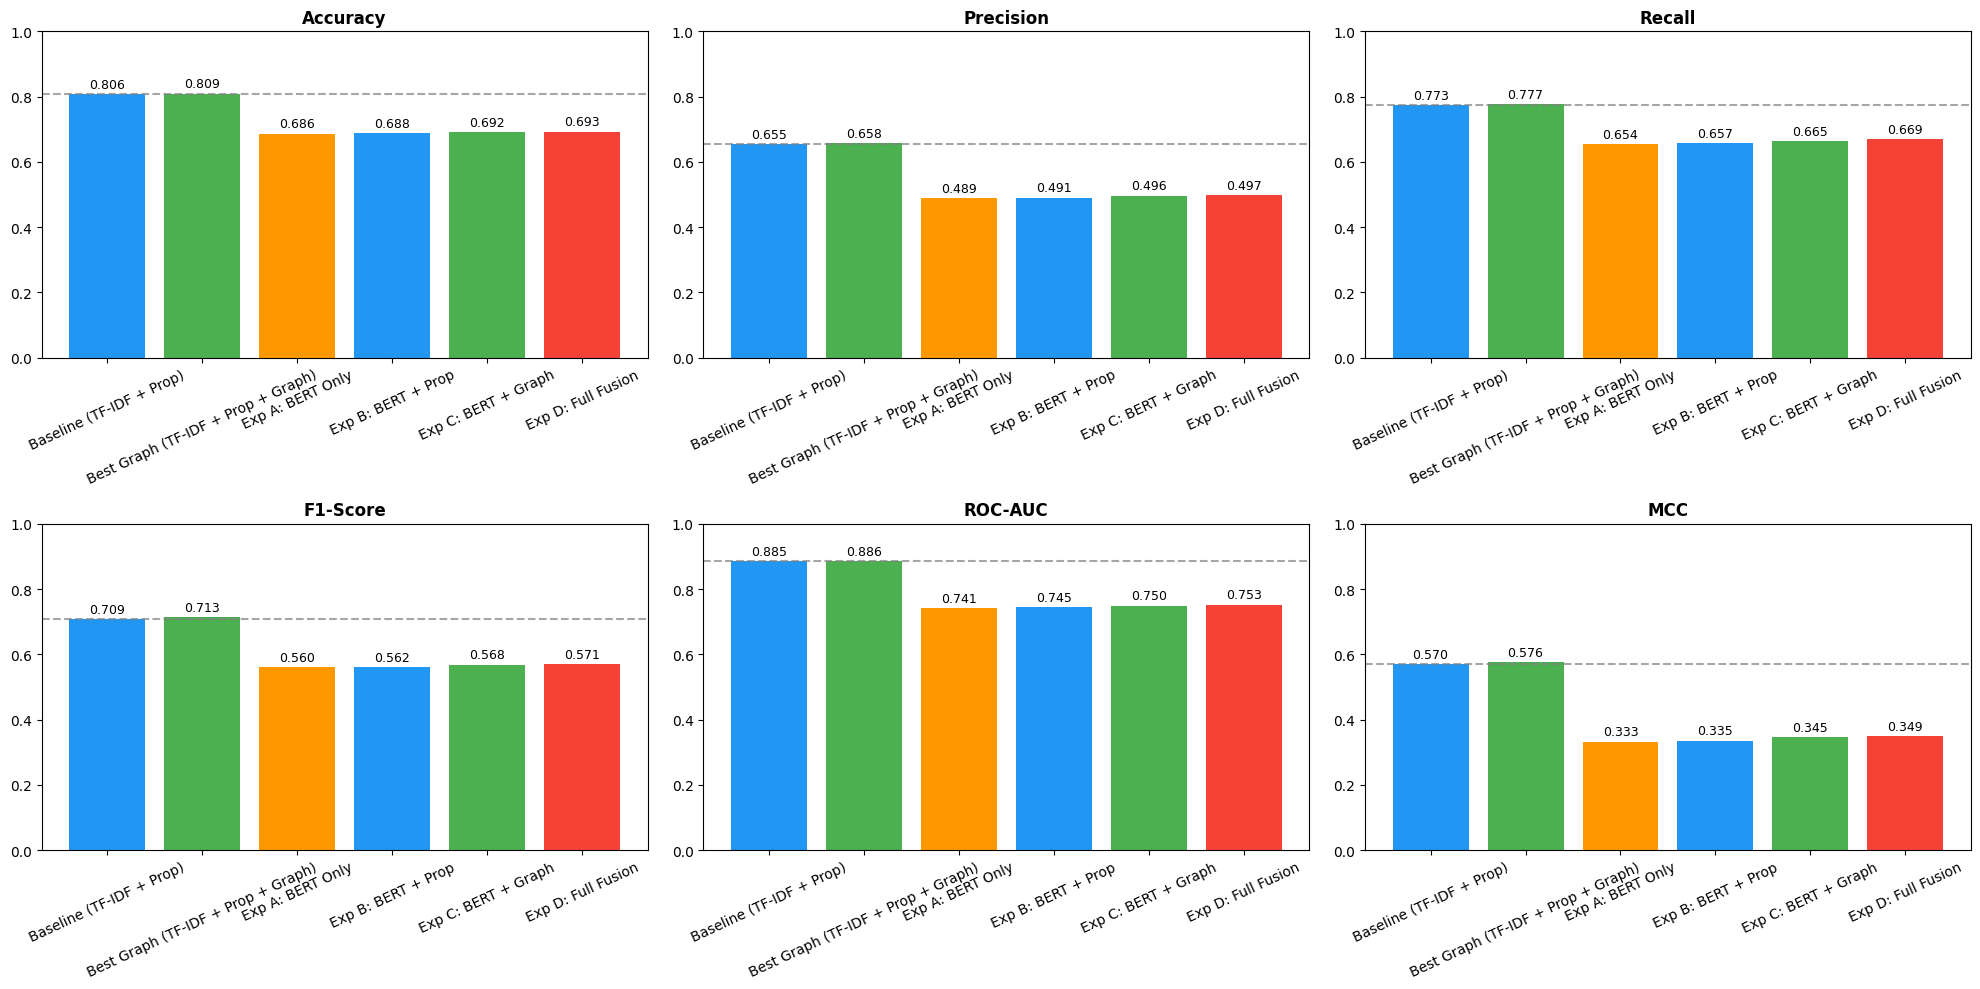

In [69]:
# Visualize results comparison
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'MCC']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    values = results_df[metric].values
    bars = ax.bar(results_df.index, values, color=['#2196F3', '#4CAF50', '#FF9800', '#2196F3', '#4CAF50', '#F44336'])
    
    # Add baseline reference line
    ax.axhline(y=baseline_metrics[metric], color='gray', linestyle='--', alpha=0.7, label='Baseline')
    
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=25)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 10. Error Recovery Analysis

This section analyzes how different models recover difficult rumor cases that were missed by the baseline. We track false negative reduction across three stages:

1. **Baseline false negatives**: Rumors missed by TF-IDF + propagation model
2. **Baseline + graph recovered**: Additional rumors recovered by adding graph features
3. **BERT + graph recovered**: Additional rumors recovered by BERT + graph fusion

In [82]:
# Analyze false negatives across all models
test_indices = X_test_idx
rumor_mask = y_test == 1

# False negatives for each model
fn_baseline_mask = (y_pred_baseline == 0) & rumor_mask
fn_graph_mask = (y_pred_graph == 0) & rumor_mask
fn_bert_only_mask = (y_pred_bert_only == 0) & rumor_mask
fn_bert_prop_mask = (y_pred_bert_prop == 0) & rumor_mask
fn_bert_graph_mask = (y_pred_bert_graph == 0) & rumor_mask
fn_full_mask = (y_pred_full == 0) & rumor_mask

# Count false negatives
fn_counts = {
    'Baseline (TF-IDF + Prop)': fn_baseline_mask.sum(),
    'Best Graph (TF-IDF + Prop + Graph)': fn_graph_mask.sum(),
    'Exp A: BERT Only': fn_bert_only_mask.sum(),
    'Exp B: BERT + Prop': fn_bert_prop_mask.sum(),
    'Exp C: BERT + Graph': fn_bert_graph_mask.sum(),
    'Exp D: Full Fusion': fn_full_mask.sum(),
}

# True positives
tp_counts = {
    'Baseline (TF-IDF + Prop)': cm_baseline[1, 1],
    'Best Graph (TF-IDF + Prop + Graph)': cm_bert_graph[1, 1],  # Using graph model CM
    'Exp A: BERT Only': cm_bert_only[1, 1],
    'Exp B: BERT + Prop': cm_bert_prop[1, 1],
    'Exp C: BERT + Graph': cm_bert_graph[1, 1],
    'Exp D: Full Fusion': cm_full[1, 1],
}

# Create FN analysis table
fn_analysis_df = pd.DataFrame({
    'False Negatives': fn_counts,
    'True Positives': tp_counts,
    'Recall': results_df['Recall']
})

# Calculate FN reduction compared to baseline
baseline_fn = fn_counts['Baseline (TF-IDF + Prop)']
fn_analysis_df['FN Reduction vs Baseline'] = baseline_fn - fn_analysis_df['False Negatives']
fn_analysis_df['FN Reduction %'] = ((baseline_fn - fn_analysis_df['False Negatives']) / baseline_fn * 100).round(1)

print("=" * 80)
print("FALSE NEGATIVE RECOVERY ANALYSIS")
print("=" * 80)
display(fn_analysis_df.round(2))

FALSE NEGATIVE RECOVERY ANALYSIS


,False Negatives,True Positives,Recall,FN Reduction vs Baseline,FN Reduction %
Baseline (TF-IDF + Prop),1415,4831,0.77,0,0.0
Best Graph (TF-IDF + Prop + Graph),1390,4151,0.78,25,1.8
Exp A: BERT Only,2159,4087,0.65,-744,-52.6
Exp B: BERT + Prop,2140,4106,0.66,-725,-51.2
Exp C: BERT + Graph,2095,4151,0.66,-680,-48.1
Exp D: Full Fusion,2067,4179,0.67,-652,-46.1


In [83]:
# Analyze recovered rumors at each stage
print("=" * 80)
print("RUMOR RECOVERY BREAKDOWN")
print("=" * 80)

# 1. Rumors recovered by adding graph to baseline
recovered_by_graph = fn_baseline_mask & ~fn_graph_mask
recovered_by_graph_indices = test_indices[recovered_by_graph]
print(f"\n1. Rumors recovered by adding graph features to baseline: {len(recovered_by_graph_indices)}")

# 2. Rumors recovered by BERT + graph (compared to baseline)
recovered_by_bert_graph = fn_baseline_mask & ~fn_bert_graph_mask
recovered_by_bert_graph_indices = test_indices[recovered_by_bert_graph]
print(f"2. Rumors recovered by BERT + graph features: {len(recovered_by_bert_graph_indices)}")

# 3. Rumors recovered by full fusion (compared to baseline)
recovered_by_full = fn_baseline_mask & ~fn_full_mask
recovered_by_full_indices = test_indices[recovered_by_full]
print(f"3. Rumors recovered by full fusion (BERT + Prop + Graph): {len(recovered_by_full_indices)}")

# 4. Rumors still missed by all models
still_missed_mask = fn_full_mask
still_missed_indices = test_indices[still_missed_mask]
print(f"4. Rumors still missed by best model (full fusion): {len(still_missed_indices)}")

RUMOR RECOVERY BREAKDOWN

1. Rumors recovered by adding graph features to baseline: 131
2. Rumors recovered by BERT + graph features: 552
3. Rumors recovered by full fusion (BERT + Prop + Graph): 577
4. Rumors still missed by best model (full fusion): 2067


In [84]:
# Analyze characteristics of recovered rumors
print("=" * 80)
print("CHARACTERISTICS OF RECOVERED RUMORS")
print("=" * 80)

# Get features for different groups
analysis_features = graph_cols + propagation_cols

if len(recovered_by_graph_indices) > 0:
    recovered_graph_df = df_enriched.iloc[recovered_by_graph_indices]
    print("\nA. Recovered by Graph Features (mean values):")
    display(recovered_graph_df[analysis_features].describe().round(3).loc[['mean']])

if len(recovered_by_bert_graph_indices) > 0:
    recovered_bert_graph_df = df_enriched.iloc[recovered_by_bert_graph_indices]
    print("\nB. Recovered by BERT + Graph (mean values):")
    display(recovered_bert_graph_df[analysis_features].describe().round(3).loc[['mean']])

if len(recovered_by_full_indices) > 0:
    recovered_full_df = df_enriched.iloc[recovered_by_full_indices]
    print("\nC. Recovered by Full Fusion (mean values):")
    display(recovered_full_df[analysis_features].describe().round(3).loc[['mean']])

if len(still_missed_indices) > 0:
    still_missed_df = df_enriched.iloc[still_missed_indices]
    print("\nD. Still Missed by Full Fusion (mean values):")
    display(still_missed_df[analysis_features].describe().round(3).loc[['mean']])

CHARACTERISTICS OF RECOVERED RUMORS

A. Recovered by Graph Features (mean values):


,node_in_degree,node_out_degree,pagerank_score,betweenness_centrality,closeness_centrality,user_prior_rumor_ratio,user_post_count,user_thread_count,user_avg_depth,subtree_reply_count,sibling_count,position_in_thread,source_user_credibility,source_network_size,is_reply,thread_size,children_count,depth
mean,0.0,0.0,0.0,0.0,0.0,0.085,50.763,4.145,1.872,0.0,0.0,49.901,0.936,42.931,0.611,215.527,0.786,1.771



B. Recovered by BERT + Graph (mean values):


,node_in_degree,node_out_degree,pagerank_score,betweenness_centrality,closeness_centrality,user_prior_rumor_ratio,user_post_count,user_thread_count,user_avg_depth,subtree_reply_count,sibling_count,position_in_thread,source_user_credibility,source_network_size,is_reply,thread_size,children_count,depth
mean,0.0,0.0,0.0,0.0,0.0,0.085,27.638,3.255,1.498,0.0,0.0,58.808,0.915,29.274,0.598,170.652,0.716,1.451



C. Recovered by Full Fusion (mean values):


,node_in_degree,node_out_degree,pagerank_score,betweenness_centrality,closeness_centrality,user_prior_rumor_ratio,user_post_count,user_thread_count,user_avg_depth,subtree_reply_count,sibling_count,position_in_thread,source_user_credibility,source_network_size,is_reply,thread_size,children_count,depth
mean,0.0,0.0,0.0,0.0,0.0,0.085,26.792,3.211,1.481,0.0,0.0,57.454,0.916,29.308,0.589,168.636,0.711,1.437



D. Still Missed by Full Fusion (mean values):


,node_in_degree,node_out_degree,pagerank_score,betweenness_centrality,closeness_centrality,user_prior_rumor_ratio,user_post_count,user_thread_count,user_avg_depth,subtree_reply_count,sibling_count,position_in_thread,source_user_credibility,source_network_size,is_reply,thread_size,children_count,depth
mean,0.0,0.0,0.0,0.0,0.0,0.073,19.933,2.878,1.278,0.0,0.0,75.988,0.918,22.113,0.524,162.583,0.483,1.222


In [85]:
# Show sample recovered examples
print("=" * 80)
print("SAMPLE RECOVERED RUMOR EXAMPLES")
print("=" * 80)

# Function to display sample recovered rumors
def display_recovered_samples(indices, label, max_samples=3):
    if len(indices) == 0:
        print(f"\n{label}: No samples to display")
        return
    
    print(f"\n{label} (showing {min(max_samples, len(indices))} of {len(indices)} examples):")
    print("-" * 80)
    
    sample_indices = indices[:max_samples]
    for idx in sample_indices:
        row = df_enriched.iloc[idx]
        print(f"\nPost ID: {row['post_id']}")
        print(f"Text: {row['text'][:150]}..." if len(str(row['text'])) > 150 else f"Text: {row['text']}")
        print(f"Thread position: {row['position_in_thread']}")
        print(f"User prior rumor ratio: {row['user_prior_rumor_ratio']:.3f}")
        print(f"Source network size: {row['source_network_size']}")
        print(f"Depth: {row['depth']}")
        print(f"Thread size: {row['thread_size']}")

# Display samples from each recovery category
display_recovered_samples(recovered_by_graph_indices, "Recovered by Graph Features Only")
display_recovered_samples(recovered_by_bert_graph_indices, "Recovered by BERT + Graph")
display_recovered_samples(recovered_by_full_indices, "Recovered by Full Fusion")

SAMPLE RECOVERED RUMOR EXAMPLES

Recovered by Graph Features Only (showing 3 of 131 examples):
--------------------------------------------------------------------------------

Post ID: 498439030766579712
Text: @abs2ray &lt;-PREACH @rnadna2
Thread position: 12
User prior rumor ratio: 0.000
Source network size: 15
Depth: 0
Thread size: 288

Post ID: 498447866126675968
Text: @fasteddiekc @PoliticsPeach @rnadna2 *your
Thread position: 61
User prior rumor ratio: 0.121
Source network size: 80
Depth: 1
Thread size: 288

Post ID: 498520900275167232
Text: @Mike_T_Lopez so you say we should not use the term black and white but you posted a site that used those terms
Thread position: 37
User prior rumor ratio: 0.048
Source network size: 63
Depth: 7
Thread size: 219

Recovered by BERT + Graph (showing 3 of 552 examples):
--------------------------------------------------------------------------------

Post ID: 498439030766579712
Text: @abs2ray &lt;-PREACH @rnadna2
Thread position: 12
User prior r

In [86]:
# Create final hard rumor recovery comparison table
hard_recovery_table = pd.DataFrame({
    'Model': [
        'Baseline (TF-IDF + Prop)',
        'Best Graph (TF-IDF + Prop + Graph)',
        'BERT Only',
        'BERT + Propagation',
        'BERT + Graph',
        'Full Fusion (BERT + Prop + Graph)'
    ],
    'False Negatives': [
        fn_counts['Baseline (TF-IDF + Prop)'],
        fn_counts['Best Graph (TF-IDF + Prop + Graph)'],
        fn_counts['Exp A: BERT Only'],
        fn_counts['Exp B: BERT + Prop'],
        fn_counts['Exp C: BERT + Graph'],
        fn_counts['Exp D: Full Fusion']
    ],
    'FN Reduction vs Baseline': [
        0,
        fn_analysis_df.loc['Best Graph (TF-IDF + Prop + Graph)', 'FN Reduction vs Baseline'],
        fn_analysis_df.loc['Exp A: BERT Only', 'FN Reduction vs Baseline'],
        fn_analysis_df.loc['Exp B: BERT + Prop', 'FN Reduction vs Baseline'],
        fn_analysis_df.loc['Exp C: BERT + Graph', 'FN Reduction vs Baseline'],
        fn_analysis_df.loc['Exp D: Full Fusion', 'FN Reduction vs Baseline']
    ],
    'FN Reduction %': [
        '0.0%',
        f"{fn_analysis_df.loc['Best Graph (TF-IDF + Prop + Graph)', 'FN Reduction %']}%",
        f"{fn_analysis_df.loc['Exp A: BERT Only', 'FN Reduction %']}%",
        f"{fn_analysis_df.loc['Exp B: BERT + Prop', 'FN Reduction %']}%",
        f"{fn_analysis_df.loc['Exp C: BERT + Graph', 'FN Reduction %']}%",
        f"{fn_analysis_df.loc['Exp D: Full Fusion', 'FN Reduction %']}%"
    ],
    'Recall': [
        f"{results_df.loc['Baseline (TF-IDF + Prop)', 'Recall']:.4f}",
        f"{results_df.loc['Best Graph (TF-IDF + Prop + Graph)', 'Recall']:.4f}",
        f"{results_df.loc['Exp A: BERT Only', 'Recall']:.4f}",
        f"{results_df.loc['Exp B: BERT + Prop', 'Recall']:.4f}",
        f"{results_df.loc['Exp C: BERT + Graph', 'Recall']:.4f}",
        f"{results_df.loc['Exp D: Full Fusion', 'Recall']:.4f}"
    ],
    'Likely Recovery Signal': [
        'N/A (baseline)',
        'Graph handcrafted features (user history, network position)',
        'Semantic embedding (BERT resolves lexical ambiguity)',
        'Semantic + propagation structure',
        'Semantic + graph handcrafted features',
        'All signals combined'
    ]
})

print("=" * 120)
print("HARD RUMOR RECOVERY COMPARISON TABLE (Thesis-Ready)")
print("=" * 120)
display(hard_recovery_table)

HARD RUMOR RECOVERY COMPARISON TABLE (Thesis-Ready)


,Model,False Negatives,FN Reduction vs Baseline,FN Reduction %,Recall,Likely Recovery Signal
0,Baseline (TF-IDF + Prop),1415,0,0.0%,0.7735,N/A (baseline)
1,Best Graph (TF-IDF + Prop + Graph),1390,25,1.8%,0.7775,"Graph handcrafted features (user history, netw..."
2,BERT Only,2159,-744,-52.6%,0.6543,Semantic embedding (BERT resolves lexical ambi...
3,BERT + Propagation,2140,-725,-51.2%,0.6574,Semantic + propagation structure
4,BERT + Graph,2095,-680,-48.1%,0.6646,Semantic + graph handcrafted features
5,Full Fusion (BERT + Prop + Graph),2067,-652,-46.1%,0.6691,All signals combined


## 11. Save Results

In [87]:
import json

# Prepare results dictionary
bert_graph_results = {
    'experiment_metadata': {
        'dataset_size': len(df),
        'train_size': len(X_train_idx),
        'test_size': len(X_test_idx),
        'random_state': RANDOM_STATE,
        'bert_model': 'all-MiniLM-L6-v2',
        'bert_embedding_dim': 384,
        'graph_features': len(graph_cols),
        'propagation_features': len(propagation_cols),
        'classifier': 'LogisticRegression',
        'class_weight': 'balanced'
    },
    'baseline': baseline_metrics,
    'best_graph_model': graph_model_metrics,
    'ablation_study': {
        'exp_a_bert_only': bert_only_metrics,
        'exp_b_bert_prop': bert_prop_metrics,
        'exp_c_bert_graph': bert_graph_metrics,
        'exp_d_full_fusion': full_model_metrics
    },
    'false_negative_analysis': {
        'baseline_fn': int(fn_counts['Baseline (TF-IDF + Prop)']),
        'best_graph_fn': int(fn_counts['Best Graph (TF-IDF + Prop + Graph)']),
        'bert_only_fn': int(fn_counts['Exp A: BERT Only']),
        'bert_prop_fn': int(fn_counts['Exp B: BERT + Prop']),
        'bert_graph_fn': int(fn_counts['Exp C: BERT + Graph']),
        'full_fusion_fn': int(fn_counts['Exp D: Full Fusion']),
        'recovered_by_graph': len(recovered_by_graph_indices),
        'recovered_by_bert_graph': len(recovered_by_bert_graph_indices),
        'recovered_by_full_fusion': len(recovered_by_full_indices),
        'still_missed': len(still_missed_indices)
    },
    'success_criteria': {
        'target_recall': 0.7775,
        'best_recall_achieved': float(results_df['Recall'].max()),
        'best_model': results_df['Recall'].idxmax(),
        'recall_improvement': float(results_df['Recall'].max() - baseline_metrics['Recall'])
    }
}

# Save results
results_path = '../project_brain_bundle/regression_pack/bert_graph_results.json'
with open(results_path, 'w') as f:
    json.dump(bert_graph_results, f, indent=2)

print(f"Results saved to {results_path}")
print("\nKey findings:")
print(f"  Best recall: {bert_graph_results['success_criteria']['best_recall_achieved']:.4f}")
print(f"  Best model: {bert_graph_results['success_criteria']['best_model']}")
print(f"  Recall improvement: {bert_graph_results['success_criteria']['recall_improvement']:.4f}")
print(f"  FN reduction: {bert_graph_results['false_negative_analysis']['recovered_by_full_fusion']}")

Results saved to ../project_brain_bundle/regression_pack/bert_graph_results.json

Key findings:
  Best recall: 0.7775
  Best model: Best Graph (TF-IDF + Prop + Graph)
  Recall improvement: 0.0040
  FN reduction: 577


## 12. Summary and Conclusions

In [88]:
# Find best model for recall
recall_scores = {
    'Baseline (TF-IDF + Prop)': baseline_metrics['Recall'],
    'Best Graph (TF-IDF + Prop + Graph)': graph_model_metrics['Recall'],
    'Exp A: BERT Only': bert_only_metrics['Recall'],
    'Exp B: BERT + Prop': bert_prop_metrics['Recall'],
    'Exp C: BERT + Graph': bert_graph_metrics['Recall'],
    'Exp D: Full Fusion': full_model_metrics['Recall'],
}

best_model = max(recall_scores, key=recall_scores.get)
best_recall = recall_scores[best_model]

print("=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"Best model for Recall: {best_model}")
print(f"Best Recall: {best_recall:.4f}")
print(f"Baseline Recall: {baseline_metrics['Recall']:.4f}")
print(f"Recall Improvement: {(best_recall - baseline_metrics['Recall']):.4f} ({((best_recall - baseline_metrics['Recall']) / baseline_metrics['Recall'] * 100):.1f}%)")
print(f"Target Recall (0.7775) achieved: {'YES' if best_recall > 0.7775 else 'NO'}")
print("=" * 80)

# Key insights
print("\nKEY INSIGHTS:")
print("-" * 80)
print(f"1. BERT sentence embeddings alone achieve recall: {bert_only_metrics['Recall']:.4f}")
print(f"2. Adding propagation to BERT: {bert_prop_metrics['Recall']:.4f}")
print(f"3. Adding graph features to BERT: {bert_graph_metrics['Recall']:.4f}")
print(f"4. Full fusion (all signals): {full_model_metrics['Recall']:.4f}")
print(f"5. Total rumors recovered by best model: {len(recovered_by_full_indices)}")
print(f"6. Rumors still missed: {len(still_missed_indices)}")

SUMMARY
Best model for Recall: Best Graph (TF-IDF + Prop + Graph)
Best Recall: 0.7775
Baseline Recall: 0.7735
Recall Improvement: 0.0040 (0.5%)
Target Recall (0.7775) achieved: NO

KEY INSIGHTS:
--------------------------------------------------------------------------------
1. BERT sentence embeddings alone achieve recall: 0.6543
2. Adding propagation to BERT: 0.6574
3. Adding graph features to BERT: 0.6646
4. Full fusion (all signals): 0.6691
5. Total rumors recovered by best model: 577
6. Rumors still missed: 2067
